In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import gc

%matplotlib inline

## Data Exploratory Analysis (EDA)

In [2]:
# Lets look at the first 5 rows of the dataset!
df = pd.read_csv("../../chess_games.csv", nrows=5)
pd.set_option('display.max_columns', None)

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Information:")
df.info()

First 5 rows of the dataset:


,Event,White,Black,Result,UTCDate,UTCTime,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,ECO,Opening,TimeControl,Termination,AN
0,Classical,eisaaaa,HAMID449,1-0,2016.06.30,22:00:01,1901,1896,11.0,-11.0,D10,Slav Defense,300+5,Time forfeit,1. d4 d5 2. c4 c6 3. e3 a6 4. Nf3 e5 5. cxd5 e...
1,Blitz,go4jas,Sergei1973,0-1,2016.06.30,22:00:01,1641,1627,-11.0,12.0,C20,King's Pawn Opening: 2.b3,300+0,Normal,1. e4 e5 2. b3 Nf6 3. Bb2 Nc6 4. Nf3 d6 5. d3 ...
2,Blitz tournament,Evangelistaizac,kafune,1-0,2016.06.30,22:00:02,1647,1688,13.0,-13.0,B01,Scandinavian Defense: Mieses-Kotroc Variation,180+0,Time forfeit,1. e4 d5 2. exd5 Qxd5 3. Nf3 Bg4 4. Be2 Nf6 5....
3,Correspondence,Jvayne,Wsjvayne,1-0,2016.06.30,22:00:02,1706,1317,27.0,-25.0,A00,Van't Kruijs Opening,-,Normal,1. e3 Nf6 2. Bc4 d6 3. e4 e6 4. Nf3 Nxe4 5. Nd...
4,Blitz tournament,kyoday,BrettDale,0-1,2016.06.30,22:00:02,1945,1900,-14.0,13.0,B90,"Sicilian Defense: Najdorf, Lipnitsky Attack",180+0,Time forfeit,1. e4 c5 2. Nf3 d6 3. d4 cxd4 4. Nxd4 Nf6 5. N...



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Event            5 non-null      str    
 1   White            5 non-null      str    
 2   Black            5 non-null      str    
 3   Result           5 non-null      str    
 4   UTCDate          5 non-null      str    
 5   UTCTime          5 non-null      str    
 6   WhiteElo         5 non-null      int64  
 7   BlackElo         5 non-null      int64  
 8   WhiteRatingDiff  5 non-null      float64
 9   BlackRatingDiff  5 non-null      float64
 10  ECO              5 non-null      str    
 11  Opening          5 non-null      str    
 12  TimeControl      5 non-null      str    
 13  Termination      5 non-null      str    
 14  AN               5 non-null      str    
dtypes: float64(2), int64(2), str(11)
memory usage: 732.0 bytes


## Main Code

In [3]:
total_result = pd.Series(dtype='int64')

print("Analiz yapılıyor...")

for chunk in pd.read_csv("../../chess_games.csv", usecols=['Result'], chunksize=100000):
    cleaned_chunks = chunk[chunk['Result'] != "*" ]

    counts = cleaned_chunks['Result'].value_counts()
    total_result = total_result.add(counts, fill_value=0)

    del chunk
    gc.collect()

Analiz yapılıyor...


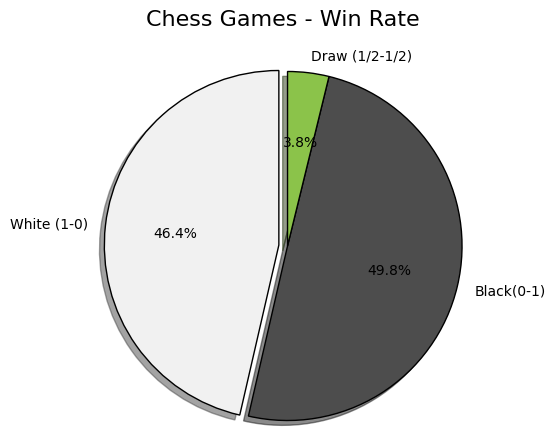

In [4]:
labels = ['White (1-0)', 'Black(0-1)', 'Draw (1/2-1/2)']
colors = ['#f1f1f1', '#4d4d4d', '#8bc34a']

plt.figure(figsize=(5, 5))
plt.pie(
    total_result.values, 
    labels=labels, 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors, 
    explode=(0.05, 0, 0),
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Chess Games - Win Rate", fontsize=16, pad=20)
plt.axis('equal')

plt.show()